# VLMEdit: Text-Guided Image Editing

Краткое описание:  
в этом проекте мы строим пайплайн для редактирования изображения по текстовой команде.  
Система находит нужный объект на изображении, строит его маску и редактирует выбранную область с помощью diffusion-модели.

Используемый пайплайн:

`Image + text instruction → Florence-2 → SAM → Canny → ControlNet + Stable Diffusion Inpainting → Edited image`

Задача проекта - показать, как можно объединить VLM, модель сегментации и diffusion-модель для controllable image editing.


In [1]:
import torch
import platform

print("Python version:", platform.python_version())
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
    print("GPU memory allocated:", round(torch.cuda.memory_allocated(0) / 1024**3, 2), "GB")
    print("GPU memory reserved:", round(torch.cuda.memory_reserved(0) / 1024**3, 2), "GB")
else:
    print("No GPU detected. Go to Runtime -> Change runtime type -> GPU")

Python version: 3.12.13
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
CUDA version: 12.8
GPU memory allocated: 0.0 GB
GPU memory reserved: 0.0 GB


In [2]:
!pip install -q -U transformers accelerate diffusers safetensors sentencepiece timm einops
!pip install -q -U pillow matplotlib opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 55.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.6.0 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.


In [3]:
!pip install -q --force-reinstall "transformers==4.49.0" "tokenizers==0.21.0"

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.0 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.6.0 which is incompatible.
datasets 4.0.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2026.6.0 which is incompatible.


In [4]:
!pip install -q "pillow<12.0,>=10.0"

In [29]:
# =========================
# Global imports
# =========================

import os
import re
import gc
import random
from pathlib import Path

import numpy as np
import torch

import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

from transformers import (
    AutoProcessor,
    AutoModelForCausalLM,
    SamModel,
    SamProcessor
)

from diffusers import StableDiffusionInpaintPipeline

import cv2

from diffusers import (
    StableDiffusionInpaintPipeline,
    ControlNetModel,
    StableDiffusionControlNetInpaintPipeline
)

In [5]:
import transformers
import tokenizers
import torch

print("transformers:", transformers.__version__)
print("tokenizers:", tokenizers.__version__)
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

assert transformers.__version__ == "4.49.0", "Wrong transformers version"
assert tokenizers.__version__ == "0.21.0", "Wrong tokenizers version"
assert torch.cuda.is_available(), "CUDA is not available"

print("Environment check passed")
print("torch:", torch.__version__)

transformers: 4.49.0
tokenizers: 0.21.0
torch: 2.11.0+cu128
CUDA available: True
Environment check passed
torch: 2.11.0+cu128


In [6]:
import PIL
import gradio

print("Pillow:", PIL.__version__)
print("Gradio:", gradio.__version__)

Pillow: 11.3.0
Gradio: 5.50.0


Number of images found: 128
First 5 image paths:
/content/data/coco128/images/train2017/000000000009.jpg
/content/data/coco128/images/train2017/000000000025.jpg
/content/data/coco128/images/train2017/000000000030.jpg
/content/data/coco128/images/train2017/000000000034.jpg
/content/data/coco128/images/train2017/000000000036.jpg


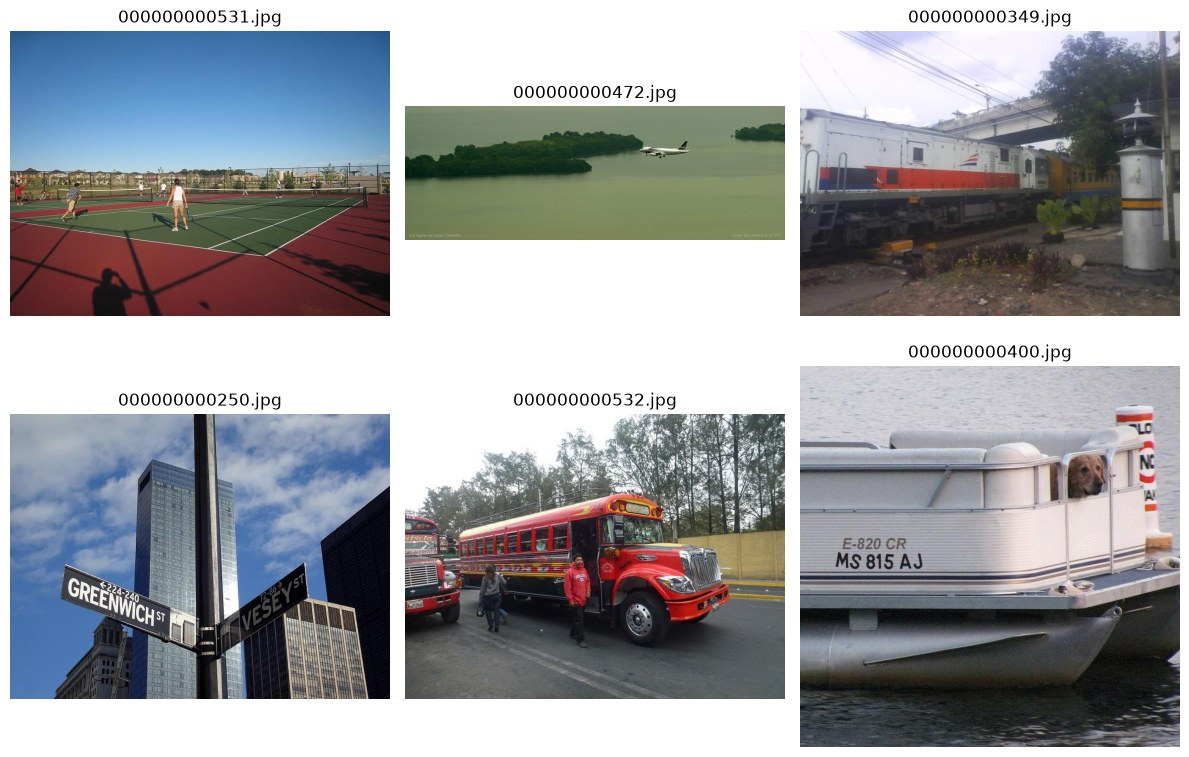

In [7]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image

DATA_DIR = Path("/content/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)

!wget -q -O /content/coco128.zip https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128.zip
!unzip -q -o /content/coco128.zip -d /content/data

image_paths = sorted(list(DATA_DIR.rglob("*.jpg")) + list(DATA_DIR.rglob("*.png")))

print("Number of images found:", len(image_paths))
print("First 5 image paths:")
for p in image_paths[:5]:
    print(p)

random.seed(41)
sample_paths = random.sample(image_paths, min(6, len(image_paths)))

plt.figure(figsize=(12, 8))
for i, path in enumerate(sample_paths):
    img = Image.open(path).convert("RGB")
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(path.name)

plt.tight_layout()
plt.show()

Selected image: /content/data/coco128/images/train2017/000000000036.jpg
Image size: (481, 640)


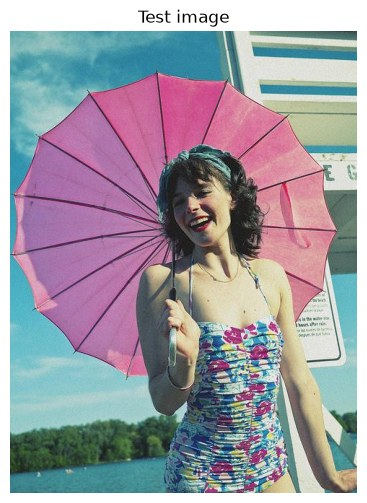

In [8]:
test_image_path = image_paths[4]

image = Image.open(test_image_path).convert("RGB")

print("Selected image:", test_image_path)
print("Image size:", image.size)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Test image")
plt.show()

In [9]:
instruction = "replace the umbrella with a yellow umbrella"
target_object = "umbrella"

print("Instruction:", instruction)
print("Target object:", target_object)

Instruction: replace the umbrella with a yellow umbrella
Target object: umbrella


In [10]:
import torch
from transformers import AutoProcessor, AutoModelForCausalLM

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

model_id = "microsoft/Florence-2-base"

print("Loading processor...")
processor = AutoProcessor.from_pretrained(
    model_id,
    trust_remote_code=True
)

print("Loading model...")
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=dtype,
    trust_remote_code=True
).to(device)

model.eval()

print("Florence-2 loaded successfully")
print("Device:", device)
print("Dtype:", dtype)
print("Model class:", model.__class__.__name__)

Loading processor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/34.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading model...


modeling_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-base:
- modeling_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/463M [00:00<?, ?B/s]

Florence-2 loaded successfully
Device: cuda
Dtype: torch.float16
Model class: Florence2ForConditionalGeneration


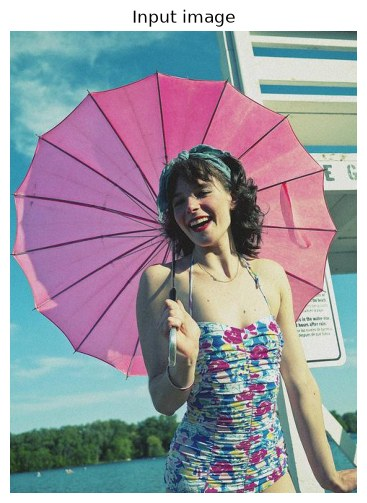

Raw output:
</s><s>a woman in a bathing suit holding an umbrella</s>

Parsed output:
{'<CAPTION>': 'a woman in a bathing suit holding an umbrella'}


In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Input image")
plt.show()

prompt = "<CAPTION>"

inputs = processor(
    text=prompt,
    images=image,
    return_tensors="pt"
).to(device, dtype)

generated_ids = model.generate(
    input_ids=inputs["input_ids"],
    pixel_values=inputs["pixel_values"],
    max_new_tokens=64,
    num_beams=3
)

generated_text = processor.batch_decode(
    generated_ids,
    skip_special_tokens=False
)[0]

parsed_answer = processor.post_process_generation(
    generated_text,
    task=prompt,
    image_size=(image.width, image.height)
)

print("Raw output:")
print(generated_text)
print("\nParsed output:")
print(parsed_answer)

Target object: umbrella
Prompt: <CAPTION_TO_PHRASE_GROUNDING>umbrella
Raw output:
</s><s>umbrella<loc_3><loc_82><loc_945><loc_754></s>

Parsed grounding:
{'<CAPTION_TO_PHRASE_GROUNDING>': {'bboxes': [[1.683500051498413, 52.79999923706055, 454.7854919433594, 482.8799743652344]], 'labels': ['umbrella']}}

BBoxes: [[1.683500051498413, 52.79999923706055, 454.7854919433594, 482.8799743652344]]
Labels: ['umbrella']

Selected bbox: [1.683500051498413, 52.79999923706055, 454.7854919433594, 482.8799743652344]


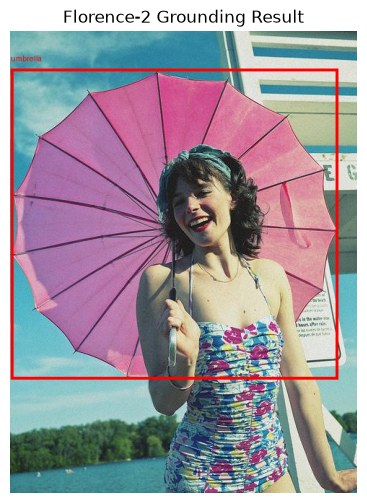

In [13]:
from PIL import ImageDraw
import matplotlib.pyplot as plt
import torch

target_object = "umbrella"
task_prompt = "<CAPTION_TO_PHRASE_GROUNDING>"
prompt = task_prompt + target_object

print("Target object:", target_object)
print("Prompt:", prompt)

inputs = processor(
    text=prompt,
    images=image,
    return_tensors="pt"
).to(device, dtype)

with torch.no_grad():
    generated_ids = model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"],
        max_new_tokens=128,
        num_beams=3
    )

generated_text = processor.batch_decode(
    generated_ids,
    skip_special_tokens=False
)[0]

parsed_grounding = processor.post_process_generation(
    generated_text,
    task=task_prompt,
    image_size=(image.width, image.height)
)

print("Raw output:")
print(generated_text)

print("\nParsed grounding:")
print(parsed_grounding)

# Extract bbox
grounding_data = parsed_grounding.get(task_prompt, {})
bboxes = grounding_data.get("bboxes", [])
labels = grounding_data.get("labels", [])

print("\nBBoxes:", bboxes)
print("Labels:", labels)

if len(bboxes) == 0:
    raise ValueError("No bounding box found for the target object.")

bbox = bboxes[0]
print("\nSelected bbox:", bbox)


image_with_bbox = image.copy()
draw = ImageDraw.Draw(image_with_bbox)

x1, y1, x2, y2 = [int(v) for v in bbox]
draw.rectangle([x1, y1, x2, y2], outline="red", width=4)
draw.text((x1, max(0, y1 - 20)), target_object, fill="red")

plt.figure(figsize=(6, 6))
plt.imshow(image_with_bbox)
plt.axis("off")
plt.title("Florence-2 Grounding Result")
plt.show()

In [14]:
from transformers import SamModel, SamProcessor

sam_model_id = "facebook/sam-vit-base"

print("Loading SAM processor...")
sam_processor = SamProcessor.from_pretrained(sam_model_id)

print("Loading SAM model...")
sam_model = SamModel.from_pretrained(sam_model_id).to(device)

sam_model.eval()

print("SAM loaded successfully")
print("Model:", sam_model_id)

Loading SAM processor...


preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

Loading SAM model...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

SAM loaded successfully
Model: facebook/sam-vit-base


Input bbox for SAM: [[[1.683500051498413, 52.79999923706055, 454.7854919433594, 482.8799743652344]]]


/usr/local/lib/python3.12/dist-packages/transformers/image_processing_utils.py:42: UserWarning: The following named arguments are not valid for `SamImageProcessor.preprocess` and were ignored: 'point_pad_value'
  return self.preprocess(images, **kwargs)


SAM mask generated successfully
Mask shape: (640, 481)
IoU scores: [0.97315854 0.9715234  0.96409845]
Selected mask index: 0


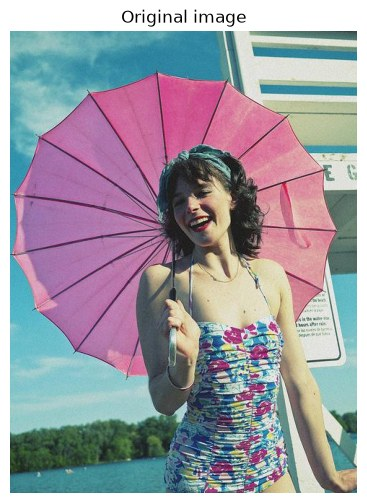

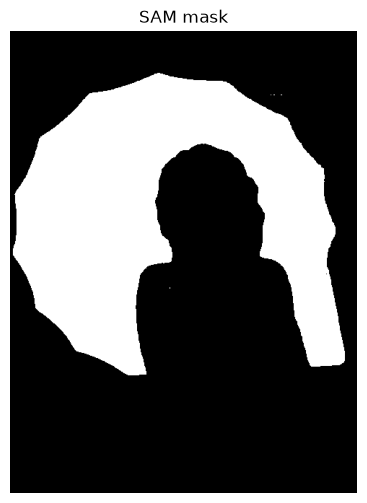

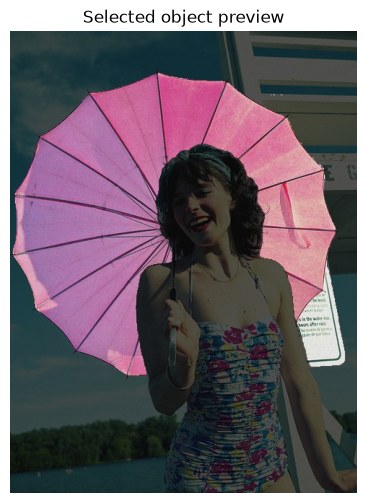

In [16]:
assert "image" in globals(), "image variable not found"
assert "bbox" in globals(), "bbox variable not found"
assert "sam_processor" in globals(), "sam_processor not found"
assert "sam_model" in globals(), "sam_model not found"

box = [float(v) for v in bbox]
input_boxes = [[box]]

print("Input bbox for SAM:", input_boxes)

inputs = sam_processor(
    images=image,
    input_boxes=input_boxes,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = sam_model(**inputs)

masks = sam_processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu()
)

scores = outputs.iou_scores.detach().cpu()
best_mask_idx = scores[0, 0].argmax().item()

mask = masks[0][0, best_mask_idx].numpy()
mask_uint8 = (mask * 255).astype(np.uint8)
mask_image = Image.fromarray(mask_uint8).convert("L")

print("SAM mask generated successfully")
print("Mask shape:", mask_uint8.shape)
print("IoU scores:", scores[0, 0].numpy())
print("Selected mask index:", best_mask_idx)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Original image")
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(mask_image, cmap="gray")
plt.axis("off")
plt.title("SAM mask")
plt.show()

image_np = np.array(image).copy()
mask_bool = mask_uint8 > 0

preview = image_np.copy()
preview[~mask_bool] = (preview[~mask_bool] * 0.35).astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(preview)
plt.axis("off")
plt.title("Selected object preview")
plt.show()

In [17]:
model.to("cpu")
sam_model.to("cpu")

gc.collect()
torch.cuda.empty_cache()


In [18]:
inpaint_model_id = "runwayml/stable-diffusion-inpainting"

print("Loading Stable Diffusion Inpainting...")

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    inpaint_model_id,
    torch_dtype=torch.float16,
    safety_checker=None
).to(device)

pipe.enable_attention_slicing()

print("Inpainting model loaded successfully")
print("Model:", inpaint_model_id)

Loading Stable Diffusion Inpainting...


model_index.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

merges.txt: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.bin:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.bin:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
You have disabled the safety checker for <class 'diffusers.pipelin

Inpainting model loaded successfully
Model: runwayml/stable-diffusion-inpainting


  0%|          | 0/30 [00:00<?, ?it/s]

Inpainting completed
Prompt: a realistic photo of a woman holding a yellow umbrella, natural lighting, same scene


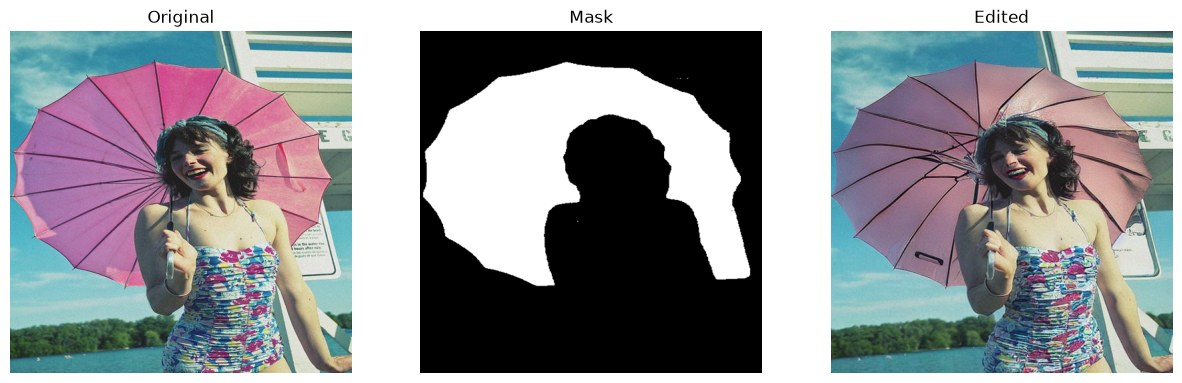

In [19]:
edit_size = 512

image_for_edit = image.resize((edit_size, edit_size))
mask_for_edit = mask_image.resize((edit_size, edit_size))

prompt = "a realistic photo of a woman holding a yellow umbrella, natural lighting, same scene"
negative_prompt = "blurry, distorted, deformed, low quality, bad anatomy, extra objects"

generator = torch.Generator(device=device).manual_seed(42)

edited_image = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=image_for_edit,
    mask_image=mask_for_edit,
    num_inference_steps=30,
    guidance_scale=7.5,
    generator=generator
).images[0]

print("Inpainting completed")
print("Prompt:", prompt)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_for_edit)
plt.axis("off")
plt.title("Original")

plt.subplot(1, 3, 2)
plt.imshow(mask_for_edit, cmap="gray")
plt.axis("off")
plt.title("Mask")

plt.subplot(1, 3, 3)
plt.imshow(edited_image)
plt.axis("off")
plt.title("Edited")

plt.show()

  0%|          | 0/40 [00:00<?, ?it/s]

Retry completed
Prompt: a realistic bright solid yellow umbrella, held by the same woman, same pose, same beach scene, natural lighting


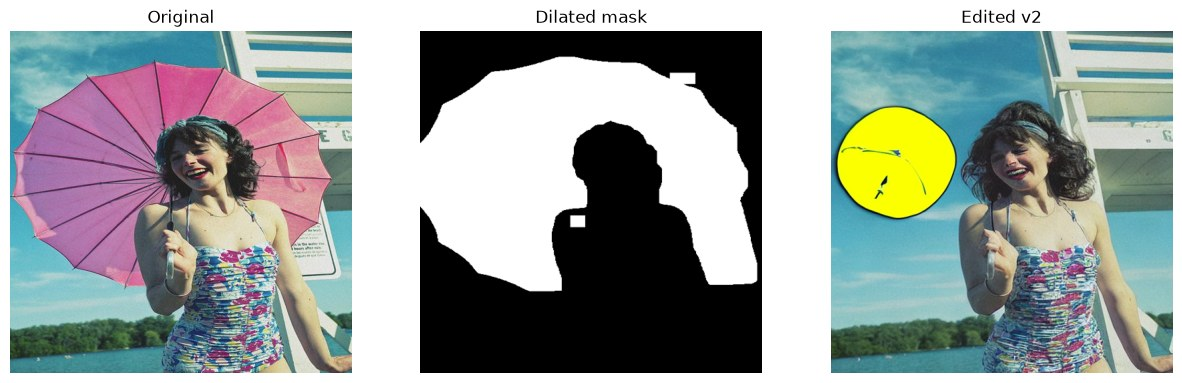

In [20]:
mask_np = np.array(mask_image)
mask_bin = (mask_np > 127).astype(np.float32)

mask_tensor = torch.tensor(mask_bin).unsqueeze(0).unsqueeze(0)
dilated_tensor = torch.nn.functional.max_pool2d(
    mask_tensor,
    kernel_size=21,
    stride=1,
    padding=10
)

dilated_mask_np = (dilated_tensor[0, 0].numpy() * 255).astype(np.uint8)
dilated_mask_image = Image.fromarray(dilated_mask_np).convert("L")


edit_size = 512
image_for_edit = image.resize((edit_size, edit_size))
mask_for_edit = dilated_mask_image.resize((edit_size, edit_size))


prompt = "a realistic bright solid yellow umbrella, held by the same woman, same pose, same beach scene, natural lighting"
negative_prompt = "red umbrella, blue umbrella, striped umbrella, multicolored umbrella, blurry, distorted, deformed, low quality, extra objects"

generator = torch.Generator(device=device).manual_seed(7)

edited_image_v2 = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=image_for_edit,
    mask_image=mask_for_edit,
    num_inference_steps=40,
    guidance_scale=10.0,
    strength=1.0,
    generator=generator
).images[0]

print("Retry completed")
print("Prompt:", prompt)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_for_edit)
plt.axis("off")
plt.title("Original")

plt.subplot(1, 3, 2)
plt.imshow(mask_for_edit, cmap="gray")
plt.axis("off")
plt.title("Dilated mask")

plt.subplot(1, 3, 3)
plt.imshow(edited_image_v2)
plt.axis("off")
plt.title("Edited v2")

plt.show()

Original bbox: (1, 52, 454, 482)
Crop box: (0, 0, 481, 640)


  0%|          | 0/40 [00:00<?, ?it/s]

Local crop inpainting completed


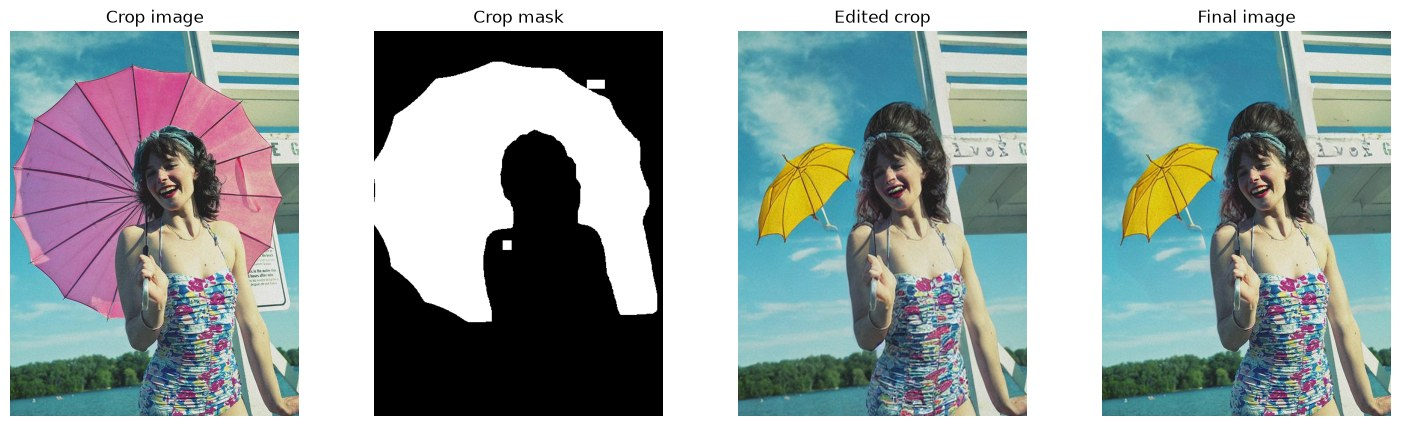

In [21]:
image_np = np.array(image)
mask_np = np.array(mask_image)

H, W = mask_np.shape


x1, y1, x2, y2 = [int(v) for v in bbox]


pad_x = int((x2 - x1) * 0.6)
pad_y = int((y2 - y1) * 0.6)

cx1 = max(0, x1 - pad_x)
cy1 = max(0, y1 - pad_y)
cx2 = min(W, x2 + pad_x)
cy2 = min(H, y2 + pad_y)

print("Original bbox:", (x1, y1, x2, y2))
print("Crop box:", (cx1, cy1, cx2, cy2))


crop_image = image.crop((cx1, cy1, cx2, cy2))
crop_mask = mask_image.crop((cx1, cy1, cx2, cy2))


crop_mask_np = np.array(crop_mask)
crop_mask_bin = (crop_mask_np > 127).astype(np.float32)

mask_tensor = torch.tensor(crop_mask_bin).unsqueeze(0).unsqueeze(0)
dilated_tensor = torch.nn.functional.max_pool2d(
    mask_tensor,
    kernel_size=15,
    stride=1,
    padding=7
)

crop_mask_dilated_np = (dilated_tensor[0, 0].numpy() * 255).astype(np.uint8)
crop_mask_dilated = Image.fromarray(crop_mask_dilated_np).convert("L")


edit_size = 512
crop_image_edit = crop_image.resize((edit_size, edit_size))
crop_mask_edit = crop_mask_dilated.resize((edit_size, edit_size))


prompt = "a realistic open yellow umbrella with a visible handle, same person, same scene, natural lighting"
negative_prompt = "circle, ball, disc, abstract shape, deformed umbrella, blurry, low quality, extra objects"

generator = torch.Generator(device=device).manual_seed(11)

edited_crop = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=crop_image_edit,
    mask_image=crop_mask_edit,
    num_inference_steps=40,
    guidance_scale=9.0,
    generator=generator
).images[0]


edited_crop_resized = edited_crop.resize(crop_image.size)


orig_crop_np = np.array(crop_image).astype(np.float32)
edited_crop_np = np.array(edited_crop_resized).astype(np.float32)
blend_mask = (np.array(crop_mask_dilated).astype(np.float32) / 255.0)[..., None]

blended_crop_np = edited_crop_np * blend_mask + orig_crop_np * (1 - blend_mask)
blended_crop_np = blended_crop_np.astype(np.uint8)
blended_crop = Image.fromarray(blended_crop_np)


final_image = image.copy()
final_image.paste(blended_crop, (cx1, cy1))

print("Local crop inpainting completed")


plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.imshow(crop_image)
plt.axis("off")
plt.title("Crop image")

plt.subplot(1, 4, 2)
plt.imshow(crop_mask_dilated, cmap="gray")
plt.axis("off")
plt.title("Crop mask")

plt.subplot(1, 4, 3)
plt.imshow(edited_crop_resized)
plt.axis("off")
plt.title("Edited crop")

plt.subplot(1, 4, 4)
plt.imshow(final_image)
plt.axis("off")
plt.title("Final image")

plt.show()

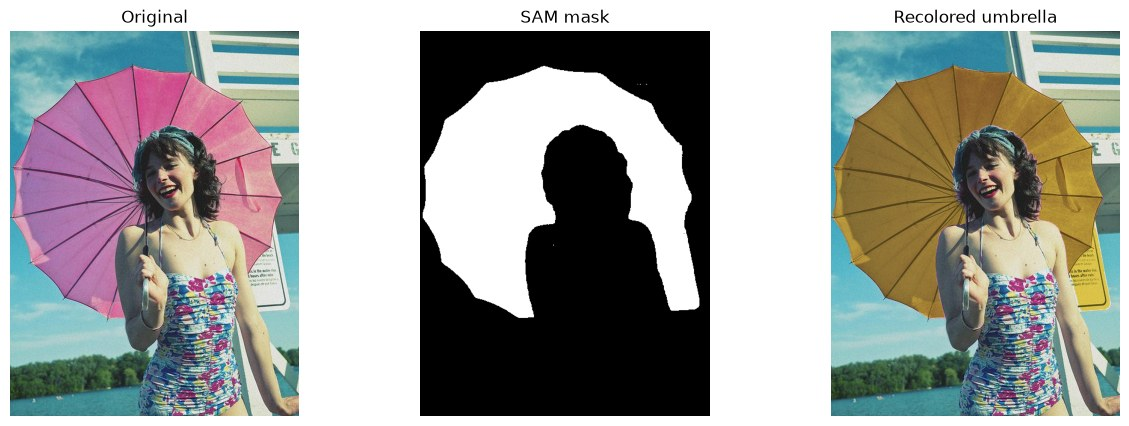

In [22]:
img_np = np.array(image).astype(np.float32)
mask_np = np.array(mask_image)


mask_bool = mask_np > 127


target_color = np.array([245, 210, 35], dtype=np.float32)


gray = (
    0.299 * img_np[:, :, 0] +
    0.587 * img_np[:, :, 1] +
    0.114 * img_np[:, :, 2]
)


masked_gray = gray[mask_bool]
g_min, g_max = masked_gray.min(), masked_gray.max()
brightness = (gray - g_min) / (g_max - g_min + 1e-6)
brightness = np.clip(brightness, 0.35, 1.15)


recolored_np = img_np.copy()

yellow_layer = target_color[None, None, :] * brightness[:, :, None]


alpha = 0.78
recolored_np[mask_bool] = (
    alpha * yellow_layer[mask_bool] +
    (1 - alpha) * img_np[mask_bool]
)

recolored_np = np.clip(recolored_np, 0, 255).astype(np.uint8)
recolored_image = Image.fromarray(recolored_np)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.axis("off")
plt.title("Original")

plt.subplot(1, 3, 2)
plt.imshow(mask_image, cmap="gray")
plt.axis("off")
plt.title("SAM mask")

plt.subplot(1, 3, 3)
plt.imshow(recolored_image)
plt.axis("off")
plt.title("Recolored umbrella")

plt.show()

  0%|          | 0/45 [00:00<?, ?it/s]

Diffusion inpainting completed: umbrella removal
Crop box: (0, 0, 481, 632)
Prompt: realistic background, blue sky and white building, the umbrella is completely, natural lighting, photo-realistic


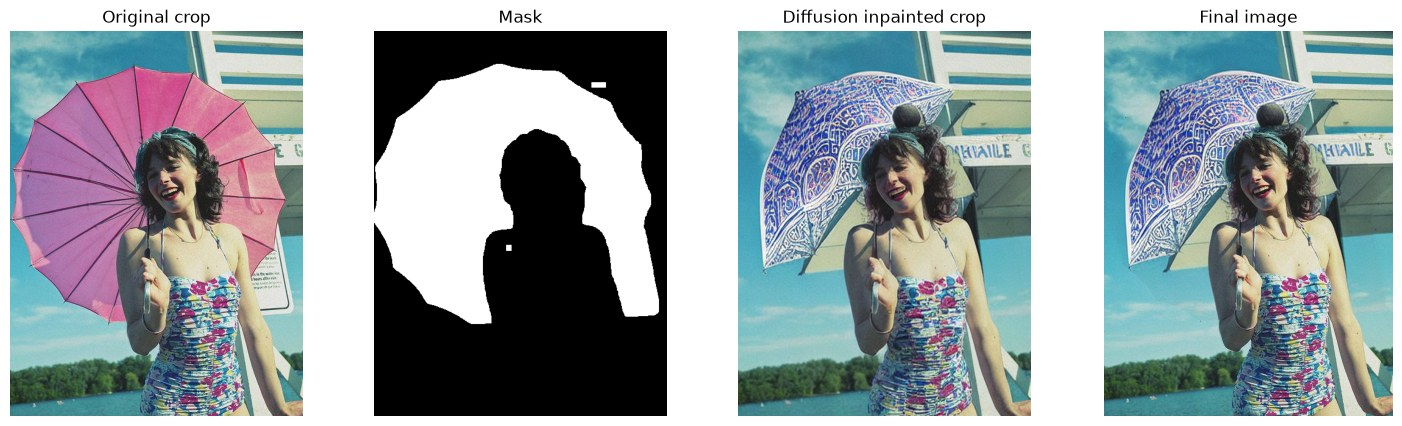

In [25]:
image_np = np.array(image)
mask_np = np.array(mask_image)

H, W = mask_np.shape


x1, y1, x2, y2 = [int(v) for v in bbox]


pad_x = int((x2 - x1) * 0.35)
pad_y = int((y2 - y1) * 0.35)

cx1 = max(0, x1 - pad_x)
cy1 = max(0, y1 - pad_y)
cx2 = min(W, x2 + pad_x)
cy2 = min(H, y2 + pad_y)

crop_image = image.crop((cx1, cy1, cx2, cy2))
crop_mask = mask_image.crop((cx1, cy1, cx2, cy2))


crop_mask_np = np.array(crop_mask)
crop_mask_bin = (crop_mask_np > 127).astype(np.float32)

mask_tensor = torch.tensor(crop_mask_bin).unsqueeze(0).unsqueeze(0)
dilated_tensor = torch.nn.functional.max_pool2d(
    mask_tensor,
    kernel_size=9,
    stride=1,
    padding=4
)

crop_mask_dilated_np = (dilated_tensor[0, 0].numpy() * 255).astype(np.uint8)
crop_mask_dilated = Image.fromarray(crop_mask_dilated_np).convert("L")


edit_size = 512
crop_image_edit = crop_image.resize((edit_size, edit_size))
crop_mask_edit = crop_mask_dilated.resize((edit_size, edit_size))

prompt = (
    "realistic background, blue sky and white building, "
    "the umbrella is completely, natural lighting, photo-realistic"
)

negative_prompt = (
    ""
)

generator = torch.Generator(device=device).manual_seed(21)

removed_crop = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    image=crop_image_edit,
    mask_image=crop_mask_edit,
    num_inference_steps=45,
    guidance_scale=8.5,
    generator=generator
).images[0]


removed_crop_resized = removed_crop.resize(crop_image.size)


orig_crop_np = np.array(crop_image).astype(np.float32)
edited_crop_np = np.array(removed_crop_resized).astype(np.float32)

blend_mask = (np.array(crop_mask_dilated).astype(np.float32) / 255.0)[..., None]

blended_crop_np = edited_crop_np * blend_mask + orig_crop_np * (1 - blend_mask)
blended_crop_np = np.clip(blended_crop_np, 0, 255).astype(np.uint8)

blended_crop = Image.fromarray(blended_crop_np)


diffusion_removed_image = image.copy()
diffusion_removed_image.paste(blended_crop, (cx1, cy1))

print("Diffusion inpainting completed: umbrella removal")
print("Crop box:", (cx1, cy1, cx2, cy2))
print("Prompt:", prompt)

plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.imshow(crop_image)
plt.axis("off")
plt.title("Original crop")

plt.subplot(1, 4, 2)
plt.imshow(crop_mask_dilated, cmap="gray")
plt.axis("off")
plt.title("Mask")

plt.subplot(1, 4, 3)
plt.imshow(removed_crop_resized)
plt.axis("off")
plt.title("Diffusion inpainted crop")

plt.subplot(1, 4, 4)
plt.imshow(diffusion_removed_image)
plt.axis("off")
plt.title("Final image")

plt.show()

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

Generated 3 candidates
Prompt: a realistic large open bright yellow umbrella behind the woman, same position, same scale, same perspective, same composition, same handle aligned with her hand, same beach scene, natural lighting, photo-realistic


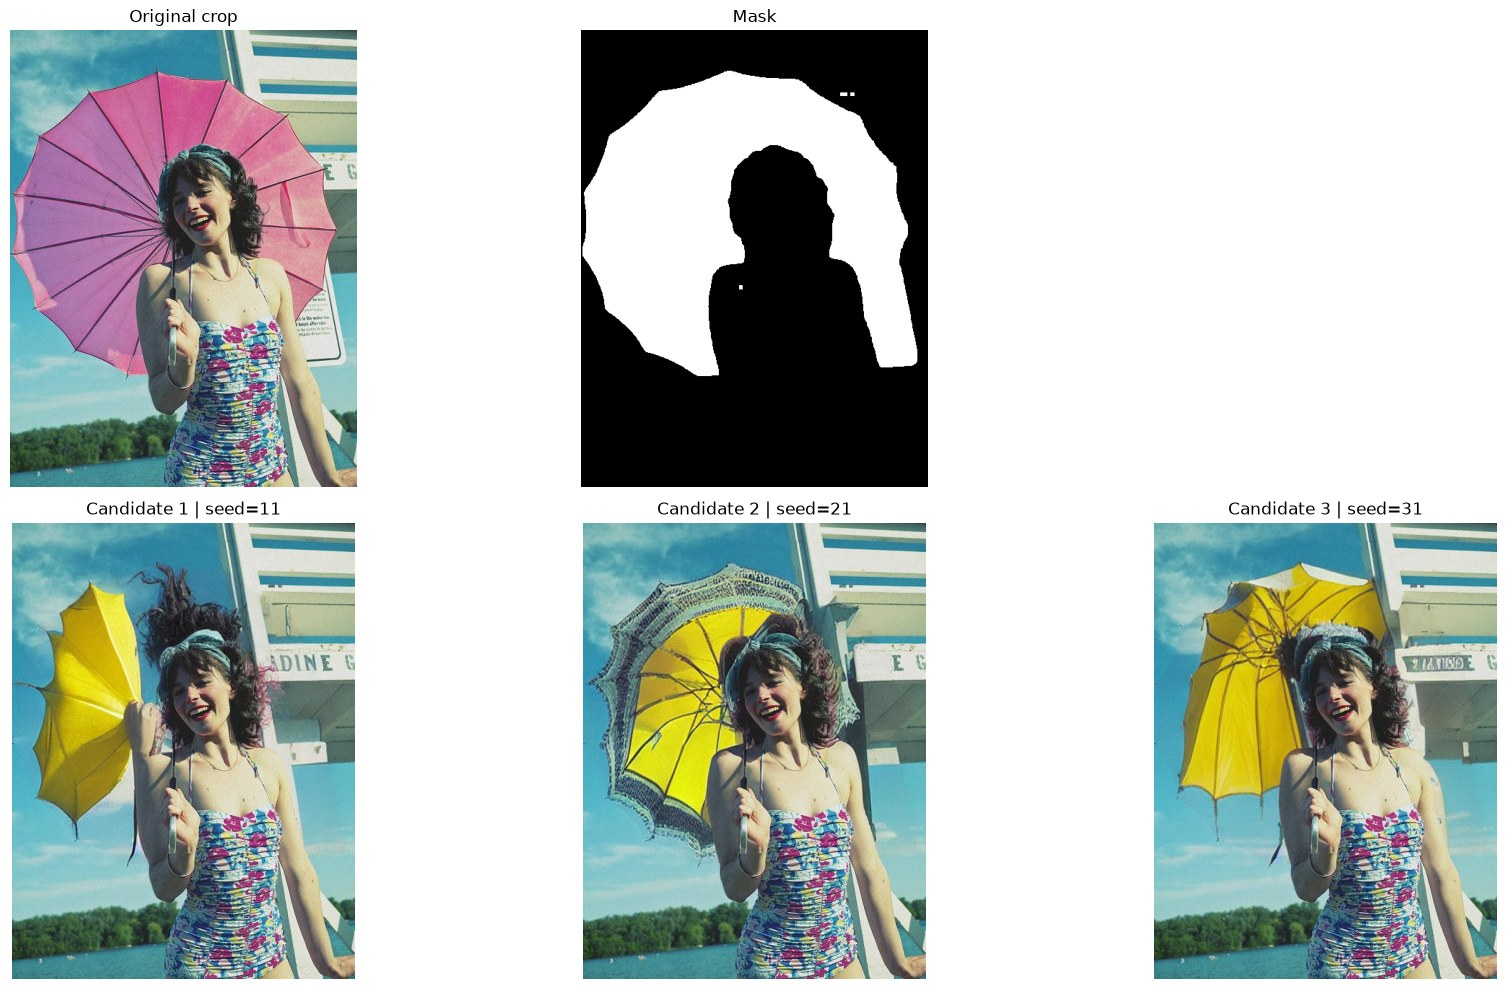

In [27]:
mask_tensor = torch.tensor(crop_mask_bin).unsqueeze(0).unsqueeze(0)
dilated_tensor = torch.nn.functional.max_pool2d(
    mask_tensor,
    kernel_size=5,
    stride=1,
    padding=2
)

crop_mask_soft_np = (dilated_tensor[0, 0].numpy() * 255).astype(np.uint8)
crop_mask_soft = Image.fromarray(crop_mask_soft_np).convert("L")

edit_size = 512
crop_image_edit = crop_image.resize((edit_size, edit_size))
crop_mask_edit = crop_mask_soft.resize((edit_size, edit_size))

prompt = (
    "a realistic large open bright yellow umbrella behind the woman, "
    "same position, same scale, same perspective, same composition, "
    "same handle aligned with her hand, same beach scene, natural lighting, photo-realistic"
)

negative_prompt = (
    "small umbrella, tiny umbrella, floating umbrella, detached umbrella, "
    "closed umbrella, parasol far away, circle, ball, abstract shape, "
    "deformed umbrella, extra umbrella, extra person, distorted, blurry, low quality"
)

seeds = [11, 21, 31]
candidates = []

for seed in seeds:
    generator = torch.Generator(device=device).manual_seed(seed)

    edited_crop = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=crop_image_edit,
        mask_image=crop_mask_edit,
        num_inference_steps=45,
        guidance_scale=11.0,
        generator=generator
    ).images[0]

    edited_crop_resized = edited_crop.resize(crop_image.size)

    orig_crop_np = np.array(crop_image).astype(np.float32)
    edited_crop_np = np.array(edited_crop_resized).astype(np.float32)
    blend_mask = (np.array(crop_mask_soft).astype(np.float32) / 255.0)[..., None]

    blended_crop_np = edited_crop_np * blend_mask + orig_crop_np * (1 - blend_mask)
    blended_crop_np = np.clip(blended_crop_np, 0, 255).astype(np.uint8)
    blended_crop = Image.fromarray(blended_crop_np)

    final_img = image.copy()
    final_img.paste(blended_crop, (cx1, cy1))

    candidates.append((seed, edited_crop_resized, final_img))

print("Generated", len(candidates), "candidates")
print("Prompt:", prompt)

plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.imshow(crop_image)
plt.axis("off")
plt.title("Original crop")

plt.subplot(2, 3, 2)
plt.imshow(crop_mask_soft, cmap="gray")
plt.axis("off")
plt.title("Mask")

for i, (seed, edited_crop_resized, final_img) in enumerate(candidates):
    plt.subplot(2, 3, i + 4)
    plt.imshow(final_img)
    plt.axis("off")
    plt.title(f"Candidate {i+1} | seed={seed}")

plt.tight_layout()
plt.show()

In [30]:
if "pipe" in globals():
    pipe.to("cpu")
    del pipe

gc.collect()
torch.cuda.empty_cache()



controlnet_id = "lllyasviel/sd-controlnet-canny"
base_model_id = "runwayml/stable-diffusion-inpainting"


controlnet = ControlNetModel.from_pretrained(
    controlnet_id,
    torch_dtype=torch.float16
)


control_pipe = StableDiffusionControlNetInpaintPipeline.from_pretrained(
    base_model_id,
    controlnet=controlnet,
    torch_dtype=torch.float16,
    safety_checker=None
).to(device)

control_pipe.enable_attention_slicing()
control_pipe.enable_vae_slicing()

Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, due to the lack of support for`float16` operations on this device in PyTorch. Please, remove the `torch_dtype=torch.float16` argument, or use another device for inference.
Pipelines loaded with `dtype=torch.float16` cannot run with `cpu` device. It is not recommended to move them to `cpu` as running them will fail. Please make sure to use an accelerator to run the pipeline in inference, du

config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-inpainting/snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
You have disabled the safety checker for <class 'diffusers.pipelin

Canny control image created
Crop box: (0, 0, 481, 589)
Crop size: (481, 589)


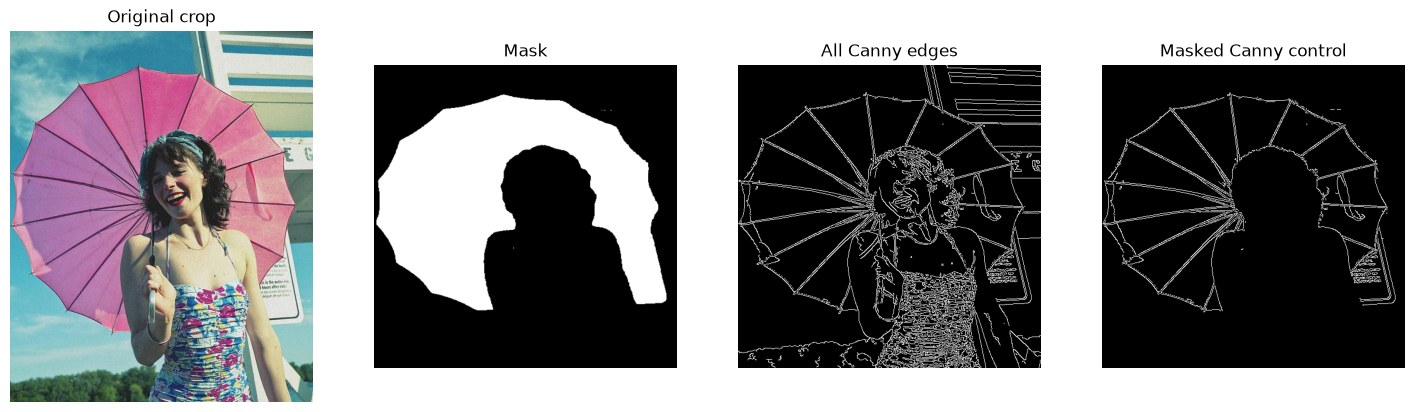

In [31]:
mask_np = np.array(mask_image)
H, W = mask_np.shape


x1, y1, x2, y2 = [int(v) for v in bbox]


pad_x = int((x2 - x1) * 0.25)
pad_y = int((y2 - y1) * 0.25)

cx1 = max(0, x1 - pad_x)
cy1 = max(0, y1 - pad_y)
cx2 = min(W, x2 + pad_x)
cy2 = min(H, y2 + pad_y)

crop_image = image.crop((cx1, cy1, cx2, cy2))
crop_mask = mask_image.crop((cx1, cy1, cx2, cy2))


edit_size = 512
crop_image_edit = crop_image.resize((edit_size, edit_size))
crop_mask_edit = crop_mask.resize((edit_size, edit_size))


crop_np = np.array(crop_image_edit)
gray = cv2.cvtColor(crop_np, cv2.COLOR_RGB2GRAY)

edges = cv2.Canny(gray, threshold1=80, threshold2=180)


mask_edit_np = np.array(crop_mask_edit)
mask_bin = (mask_edit_np > 127).astype(np.uint8)

kernel = np.ones((7, 7), np.uint8)
mask_dilated = cv2.dilate(mask_bin, kernel, iterations=1)

edges_masked = edges * mask_dilated


control_image = Image.fromarray(edges_masked).convert("RGB")

print("Canny control image created")
print("Crop box:", (cx1, cy1, cx2, cy2))
print("Crop size:", crop_image.size)

plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.imshow(crop_image)
plt.axis("off")
plt.title("Original crop")

plt.subplot(1, 4, 2)
plt.imshow(crop_mask_edit, cmap="gray")
plt.axis("off")
plt.title("Mask")

plt.subplot(1, 4, 3)
plt.imshow(edges, cmap="gray")
plt.axis("off")
plt.title("All Canny edges")

plt.subplot(1, 4, 4)
plt.imshow(control_image)
plt.axis("off")
plt.title("Masked Canny control")

plt.show()

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

Generated 3 ControlNet candidates


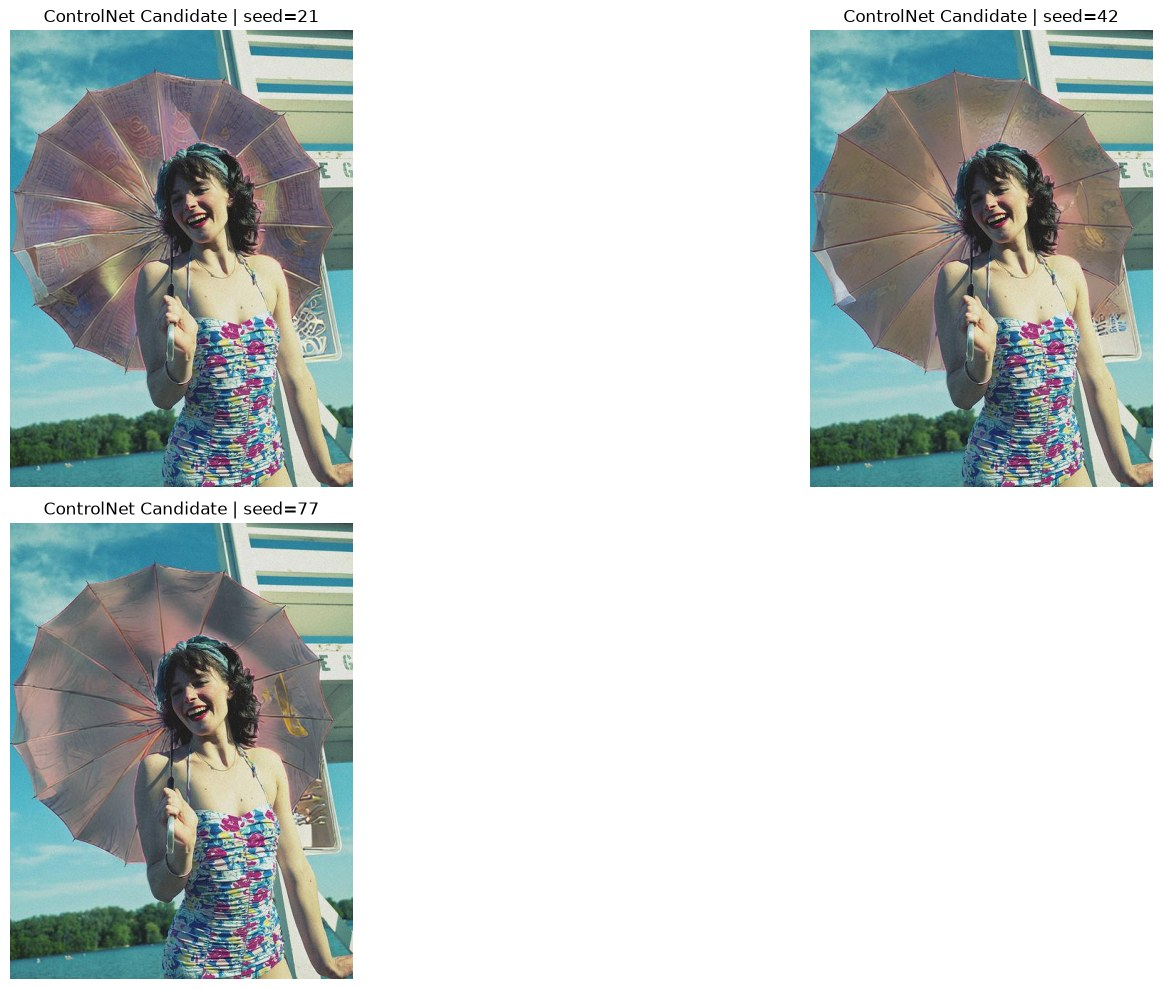

In [32]:
prompt = (
    "a realistic large open bright yellow umbrella behind the woman, "
    "same size, same position, same perspective, visible umbrella structure, "
    "same handle alignment, natural lighting, photo-realistic"
)

negative_prompt = (
    "small umbrella, tiny umbrella, detached umbrella, floating umbrella, "
    "closed umbrella, abstract shape, circle, ball, distorted, blurry, "
    "extra umbrella, low quality"
)

seeds = [21, 42, 77]
control_candidates = []

for seed in seeds:
    generator = torch.Generator(device=device).manual_seed(seed)

    edited_crop = control_pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        image=crop_image_edit,
        mask_image=crop_mask_edit,
        control_image=control_image,
        num_inference_steps=40,
        guidance_scale=9.5,
        controlnet_conditioning_scale=1.0,
        generator=generator
    ).images[0]

    edited_crop_resized = edited_crop.resize(crop_image.size)

    # Blend only masked region back into original crop
    orig_crop_np = np.array(crop_image).astype(np.float32)
    edited_crop_np = np.array(edited_crop_resized).astype(np.float32)
    blend_mask = (np.array(crop_mask_edit.resize(crop_image.size)).astype(np.float32) / 255.0)[..., None]

    blended_crop_np = edited_crop_np * blend_mask + orig_crop_np * (1 - blend_mask)
    blended_crop_np = np.clip(blended_crop_np, 0, 255).astype(np.uint8)
    blended_crop = Image.fromarray(blended_crop_np)

    final_img = image.copy()
    final_img.paste(blended_crop, (cx1, cy1))

    control_candidates.append((seed, final_img))

print("Generated", len(control_candidates), "ControlNet candidates")

plt.figure(figsize=(18, 10))

for i, (seed, final_img) in enumerate(control_candidates):
    plt.subplot(2, 2, i + 1)
    plt.imshow(final_img)
    plt.axis("off")
    plt.title(f"ControlNet Candidate | seed={seed}")

plt.tight_layout()
plt.show()

Best result saved to: /content/best_controlnet_umbrella_result.png


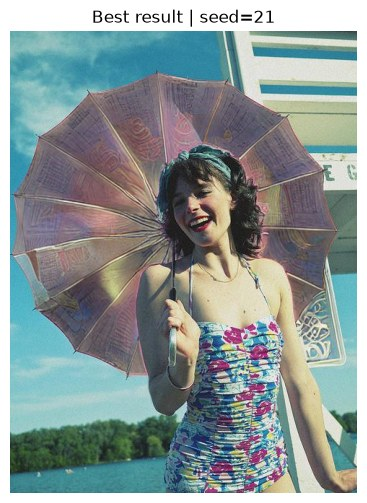

In [33]:
# =========================
# Save the best ControlNet result
# =========================

best_seed = 21

best_result = None
for seed, final_img in control_candidates:
    if seed == best_seed:
        best_result = final_img
        break

assert best_result is not None, "Best result not found"

save_path = "/content/best_controlnet_umbrella_result.png"
best_result.save(save_path)

print("Best result saved to:", save_path)

plt.figure(figsize=(6, 6))
plt.imshow(best_result)
plt.axis("off")
plt.title(f"Best result | seed={best_seed}")
plt.show()

In [34]:
def resize_to_match(img, size):
    return img.resize(size)


def compute_mask_mse(original_image, edited_image, mask_image):
    """
    Computes pixel-level MSE inside and outside the edited mask.

    inside_mse:
        How much the target object region changed.

    outside_mse:
        How much the non-target region changed.
        Lower is better.
    """

    # Make sure all images have the same size
    edited_image = resize_to_match(edited_image, original_image.size)
    mask_image = resize_to_match(mask_image, original_image.size)

    original_np = np.array(original_image).astype(np.float32)
    edited_np = np.array(edited_image).astype(np.float32)
    mask_np = np.array(mask_image)

    mask_bool = mask_np > 127
    outside_bool = ~mask_bool

    diff = (original_np - edited_np) ** 2

    if mask_bool.sum() == 0:
        inside_mse = None
    else:
        inside_mse = diff[mask_bool].mean()

    if outside_bool.sum() == 0:
        outside_mse = None
    else:
        outside_mse = diff[outside_bool].mean()

    return {
        "inside_mse": inside_mse,
        "outside_mse": outside_mse,
        "mask_area_percent": 100 * mask_bool.mean()
    }


def show_eval_result(original_image, mask_image, edited_image, title="Evaluation"):
    metrics = compute_mask_mse(original_image, edited_image, mask_image)

    print(title)
    print("Inside MSE:", round(metrics["inside_mse"], 2))
    print("Outside MSE:", round(metrics["outside_mse"], 2))
    print("Mask area %:", round(metrics["mask_area_percent"], 2))

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(original_image)
    plt.axis("off")
    plt.title("Original")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_image, cmap="gray")
    plt.axis("off")
    plt.title("Mask")

    plt.subplot(1, 3, 3)
    plt.imshow(edited_image)
    plt.axis("off")
    plt.title("Edited")

    plt.suptitle(title)
    plt.show()

    return metrics

Best ControlNet result
Inside MSE: 4078.15
Outside MSE: 0.51
Mask area %: 32.2


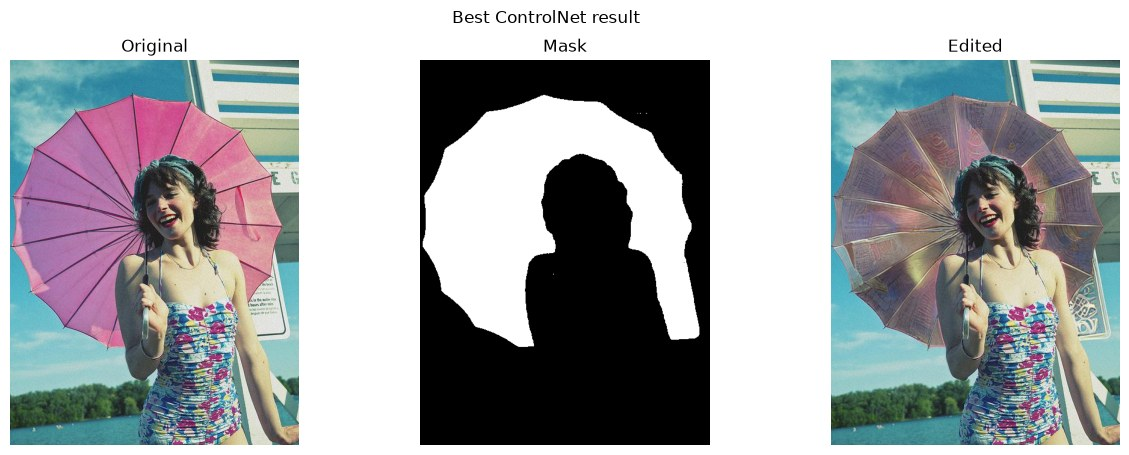

{'inside_mse': np.float32(4078.1477),
 'outside_mse': np.float32(0.5081519),
 'mask_area_percent': np.float64(32.2037422037422)}

In [35]:
control_metrics = show_eval_result(
    original_image=image,
    mask_image=mask_image,
    edited_image=best_result,
    title="Best ControlNet result"
)

control_metrics

Best ControlNet result
Inside MSE: 4078.15
Outside MSE: 0.51
Mask area %: 32.2


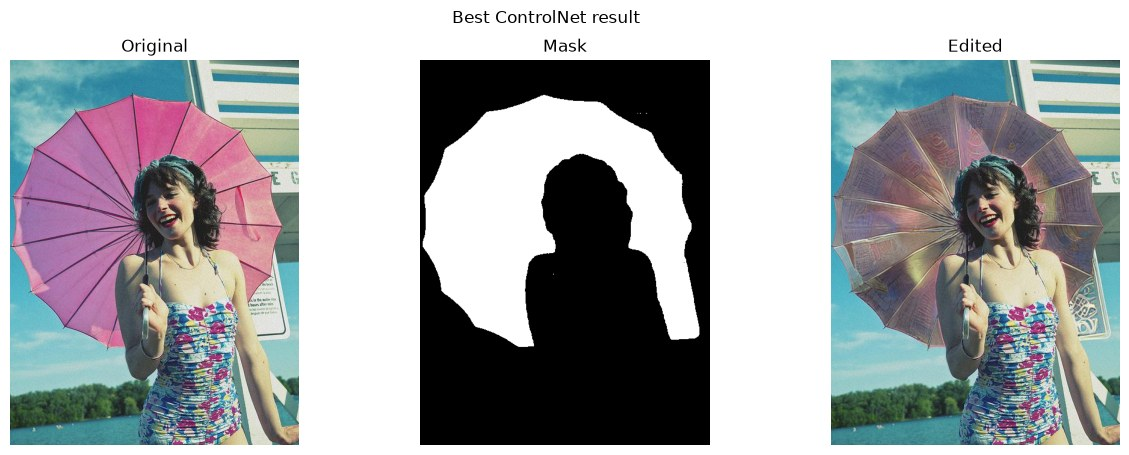

{'inside_mse': np.float32(4078.1477),
 'outside_mse': np.float32(0.5081519),
 'mask_area_percent': np.float64(32.2037422037422)}

In [36]:
best_seed = 21

best_result = None
for seed, final_img in control_candidates:
    if seed == best_seed:
        best_result = final_img
        break

assert best_result is not None, "Best result not found"

control_metrics = show_eval_result(
    original_image=image,
    mask_image=mask_image,
    edited_image=best_result,
    title="Best ControlNet result"
)

control_metrics

In [37]:
from transformers import CLIPProcessor, CLIPModel

In [38]:
clip_model_id = "openai/clip-vit-base-patch32"


clip_device = "cpu"

print("Loading CLIP...")

clip_processor = CLIPProcessor.from_pretrained(clip_model_id)
clip_model = CLIPModel.from_pretrained(clip_model_id).to(clip_device)
clip_model.eval()

print("CLIP loaded successfully")
print("Model:", clip_model_id)
print("Device:", clip_device)

Loading CLIP...


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

CLIP loaded successfully
Model: openai/clip-vit-base-patch32
Device: cpu


In [39]:
def compute_clip_score(image, text):
    """
    Computes CLIP text-image similarity.
    Higher score means better alignment between image and text.
    """

    inputs = clip_processor(
        text=[text],
        images=image,
        return_tensors="pt",
        padding=True
    ).to(clip_device)

    with torch.no_grad():
        outputs = clip_model(**inputs)

        image_embeds = outputs.image_embeds
        text_embeds = outputs.text_embeds

        image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
        text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)

        score = torch.matmul(image_embeds, text_embeds.T).item()

    return score

In [40]:
eval_prompt = "a woman holding a large yellow umbrella"

original_clip_score = compute_clip_score(image, eval_prompt)
best_clip_score = compute_clip_score(best_result, eval_prompt)

print("Evaluation prompt:", eval_prompt)
print("Original image CLIP score:", round(original_clip_score, 4))
print("Best edited image CLIP score:", round(best_clip_score, 4))

if best_clip_score > original_clip_score:
    print("Edited result is better aligned with the target prompt.")
else:
    print("Edited result is not better aligned than the original according to CLIP.")

Evaluation prompt: a woman holding a large yellow umbrella
Original image CLIP score: 0.2637
Best edited image CLIP score: 0.2957
Edited result is better aligned with the target prompt.


## Описание проекта

В этом проекте мы решали задачу текстового редактирования изображения: пользователь задаёт команду, например заменить зонт на жёлтый, а система автоматически находит нужный объект и редактирует только его.

Мы использовали мультимодальный пайплайн:

`Image + text instruction → Florence-2 → SAM → Canny → ControlNet + Stable Diffusion Inpainting → Edited image`

- **Florence-2** использовалась как VLM для поиска объекта по тексту и получения bounding box.
- **SAM** строила точную маску найденного объекта.
- **Canny** выделял контуры объекта для сохранения формы.
- **ControlNet** добавлял структурный контроль к diffusion-модели.
- **Stable Diffusion Inpainting** генерировала новую версию объекта внутри маски.
- **CLIP score** использовался для оценки соответствия результата текстовому запросу.

Главная цель проекта — показать, как VLM, segmentation model и diffusion model можно объединить в один пайплайн для controllable image editing.